In [1]:
# Step 1: Import required libraries

import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

from src.preprocessing import preprocess_data

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Step 2: Load and preprocess data

X_train, X_test, y_train, y_test = preprocess_data(
    "../data/online_gaming_behavior_dataset.csv"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (25293, 12)
Testing shape: (6324, 12)


In [3]:
print(y_train.unique())

[1 2 0]


In [4]:
# Step 3: Train baseline model

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
# Step 4: Evaluate baseline model

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9226755218216319

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91      1569
           1       0.92      0.89      0.90      1656
           2       0.92      0.96      0.94      3099

    accuracy                           0.92      6324
   macro avg       0.92      0.91      0.92      6324
weighted avg       0.92      0.92      0.92      6324



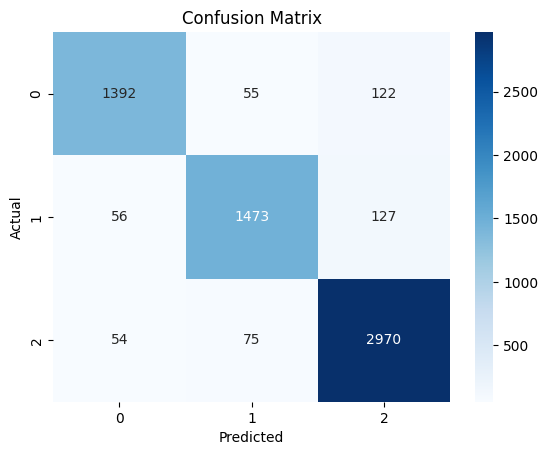

In [6]:
# Step 5: Confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

                      Feature  Importance
11        TotalWeeklyPlayTime    0.511220
7             SessionsPerWeek    0.172667
8   AvgSessionDurationMinutes    0.118108
9                 PlayerLevel    0.047586
10       AchievementsUnlocked    0.044598
4               PlayTimeHours    0.038563
0                         Age    0.028266
3                   GameGenre    0.013680
2                    Location    0.010950
6              GameDifficulty    0.008529


<Figure size 640x480 with 0 Axes>

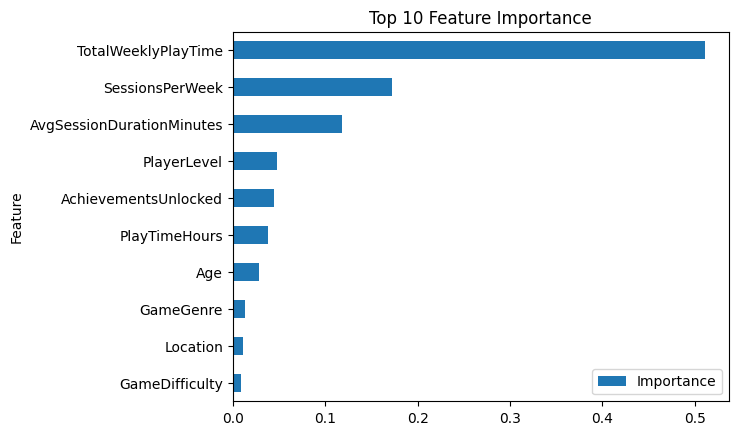

In [12]:
# Step 6: Feature importance

importances = rf_model.feature_importances_

# Get feature names
feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

plt.figure()
feat_df.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [9]:
# Step 7: Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [10]:
# Step 8: Evaluate optimized model

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Optimized Accuracy: 0.9226755218216319

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91      1569
           1       0.92      0.89      0.90      1656
           2       0.92      0.96      0.94      3099

    accuracy                           0.92      6324
   macro avg       0.92      0.91      0.92      6324
weighted avg       0.92      0.92      0.92      6324

